In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#ASSIGNMENT 1

##Part 1 : Numpy Fundamentals

Q 1.1 Array creation and statistical filtering


In [55]:
arr = np.linspace(0,20,100)

print(arr)

print(np.mean(arr))
print(np.median(arr))
print(np.std(arr))
print(np.var(arr))

[ 0.          0.2020202   0.4040404   0.60606061  0.80808081  1.01010101
  1.21212121  1.41414141  1.61616162  1.81818182  2.02020202  2.22222222
  2.42424242  2.62626263  2.82828283  3.03030303  3.23232323  3.43434343
  3.63636364  3.83838384  4.04040404  4.24242424  4.44444444  4.64646465
  4.84848485  5.05050505  5.25252525  5.45454545  5.65656566  5.85858586
  6.06060606  6.26262626  6.46464646  6.66666667  6.86868687  7.07070707
  7.27272727  7.47474747  7.67676768  7.87878788  8.08080808  8.28282828
  8.48484848  8.68686869  8.88888889  9.09090909  9.29292929  9.49494949
  9.6969697   9.8989899  10.1010101  10.3030303  10.50505051 10.70707071
 10.90909091 11.11111111 11.31313131 11.51515152 11.71717172 11.91919192
 12.12121212 12.32323232 12.52525253 12.72727273 12.92929293 13.13131313
 13.33333333 13.53535354 13.73737374 13.93939394 14.14141414 14.34343434
 14.54545455 14.74747475 14.94949495 15.15151515 15.35353535 15.55555556
 15.75757576 15.95959596 16.16161616 16.36363636 16

Q 1.2 Reshaping:
      

In [56]:
#creating a 1d array from 1 to 36
arr = np.arange(1,37)
print("Orginal array shape:", arr.shape)

#Reshaping the array to 4x9
matrix = arr.reshape(4,9)
print("Reshaped matrix shape:", matrix.shape)

#flatten back to 1d
flat = matrix.flatten()
print("Flattened array shape:", flat.shape)

Orginal array shape: (36,)
Reshaped matrix shape: (4, 9)
Flattened array shape: (36,)


## Part 2 : Pandas & Data Wrangling


In [57]:
df = sns.load_dataset('titanic')

Q 2.1 First Look

In [58]:
df.head() #to see the first 5 rows of the dataset
df.info() #to understand column names, data types, and missing values
df.describe() #to view summary statistics such as mean, median, maxm., minm., values for numerical columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Q 2.2 Missing Value Treatment


In [59]:
# listing every column with missing values along with their count and percentage missing
missing_count = df.isnull().sum()

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing Percentage' : missing_percent
})

missing_summary[missing_summary['Missing Count'] > 0]

#fill missing age values using median age of each passenger class
df['age'] = df['age'].fillna(
    df.groupby('pclass')['age'].transform('median')
)

#fill missing embarked values using mode
df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

#drop deck column
df = df.drop(columns=['deck'])



We dropped the DECK COLUMN since the 'deck' column contains a very large number of missing values. Since most of the entries are missing, filling them would not be reliable and could introduce incorrect information into the dataset. Therefore, dropping the column is a better option because it contributes very little useful information compared to the amount of missing data it contains.

In [60]:
#verifying missing values in treated columns
print("missing values in age:")
print(df['age'].isnull().sum())

print("Missing values in embarked:")
print(df['embarked'].isnull())


missing values in age:
0
Missing values in embarked:
0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: embarked, Length: 891, dtype: bool


# Part 3 : Matplotlib Visualizations

Q 3.1 Histogram of Age

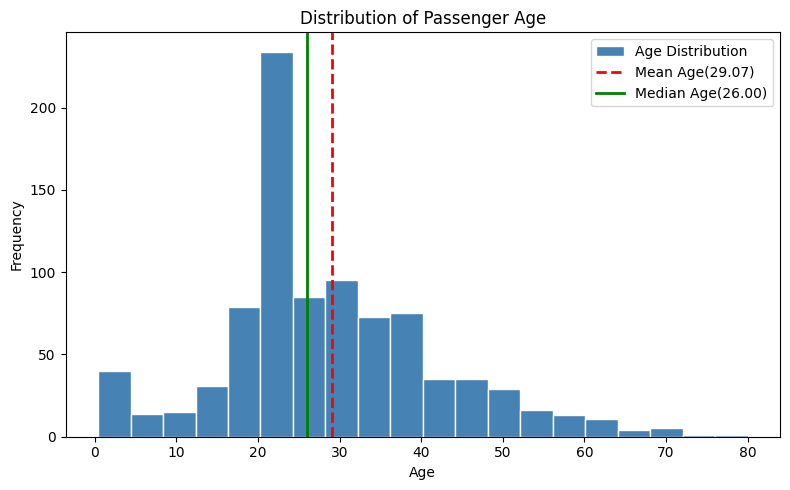

In [61]:
#Cacluating mean and median
mean_age = df['age'].mean()
median_age = df['age'].median()

plt.figure(figsize=(8,5))

plt.hist(
    df['age'],
    bins=20,
    color='steelblue',
    edgecolor='white',
    label='Age Distribution'
)

plt.axvline(
    mean_age,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean Age({mean_age:.2f})'
)

plt.axvline(
    median_age,
    color='green',
    linewidth=2,
    label=f'Median Age({median_age:.2f})'
)

plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

Q 3.2 Scatter Plot with Color Encoding

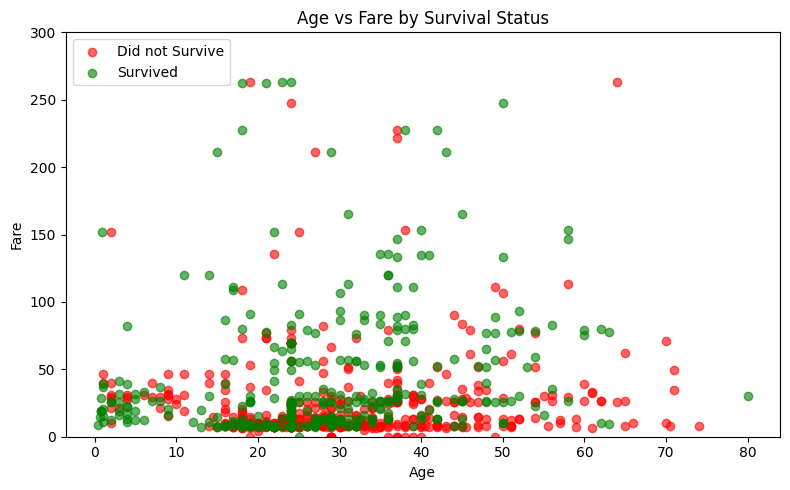

In [62]:
plt.figure(figsize=(8,5))

#Passengers who didn't survive
not_survived = df[df['survived'] == 0]

#Passengers who survived
survived = df[df['survived'] == 1]

plt.scatter(
    not_survived['age'],
    not_survived['fare'],
    color='red',
    alpha=0.6,
    label='Did not Survive'
)

plt.scatter(
    survived['age'],
    survived['fare'],
    color='green',
    alpha=0.6,
    label='Survived'
)

plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')

#Cap y-axis
plt.ylim(0, 300)

plt.legend()

plt.tight_layout()
plt.show()

This scatter plot shows the relationship between passenger age and fare paid.
- Green points represent passengers who survived
- Red points represent passengers who didn't survive.
- The y-axis has been limited to 300 to improve readability by reducing the effect of extreme fare outliers

# Part 4 : Exploratory Data Analysis
Q 4.1 Initial Inspection

In [63]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising (1).csv


In [64]:
df = pd.read_csv("advertising.csv")

#Shape of dataset
print("Shape of dataset:")
print(df.shape)

#Data Types and Missing Values
print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

#Statistical Summary
df.describe()

Shape of dataset:
(200, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


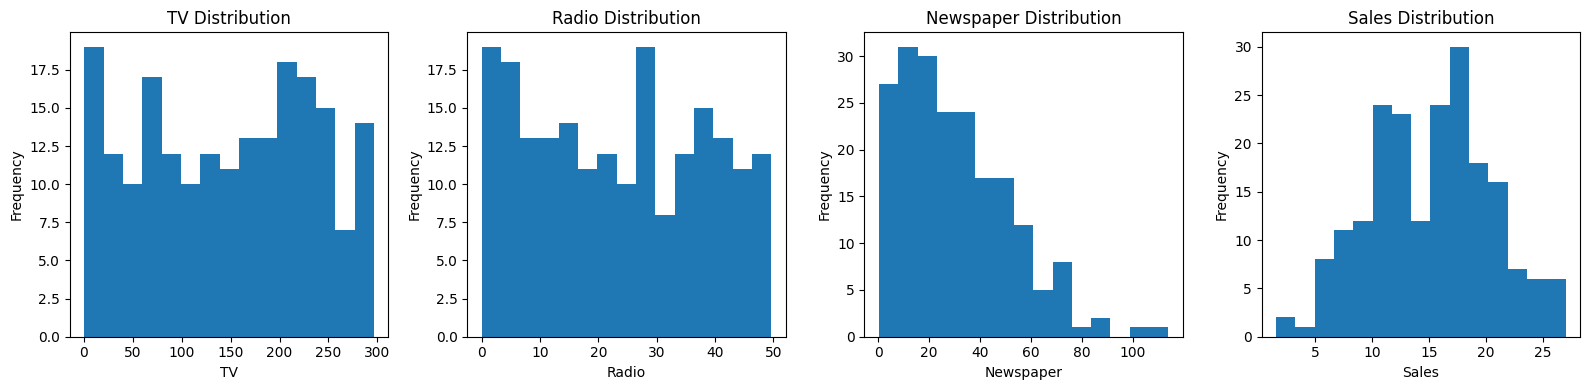

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

columns = ['TV', 'Radio', 'Newspaper', 'Sales']

for i, col in enumerate(columns):
  axes[i].hist(df[col], bins=15)
  axes[i].set_title(f'{col} Distribution')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Outlier Inspection:

From visual inspection of the histograms:

- TV spending appears relatively evenly distributed.
- Radio spending appears reasonably spread out.
- Newspaper spending may contain a few unusually large values compared to most observations.
- Sales appears fairly well distributed with no extreme outliers.

Any potential outliers should be verified using boxplots or statistical methods.

Q 4.2 Correlation Analysis


                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


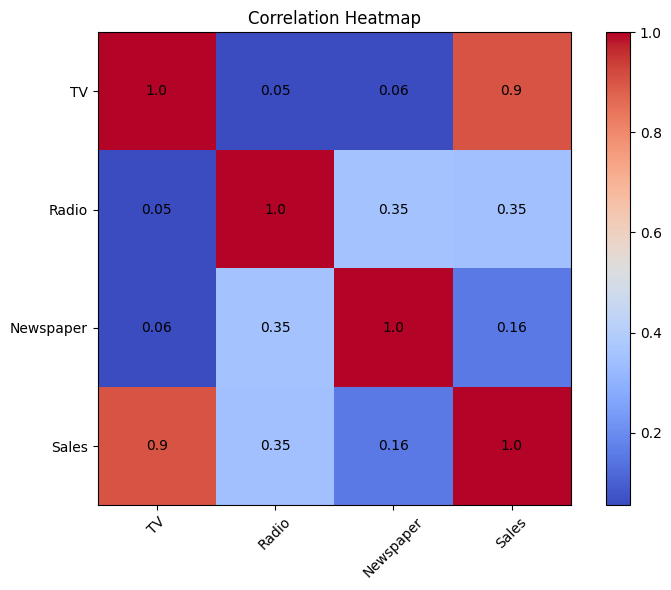

In [66]:
#Correlation matrix
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

#Heatmap using plt.imshow()
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(corr_matrix)),
    corr_matrix.columns
)

for i in range(len(corr_matrix)):
  for j in range(len(corr_matrix)):
    plt.text(
        j,i,
        round(corr_matrix.iloc[i,j], 2),
        ha='center',
        va='center'
    )

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()


Correlation Analysis

- The feature most strongly correlated with Sales is TV.
- Radio also has a positive correlation with Sales, but it is weaker than TV.
- TV and Radio have a weak positive correlation with each other, indicating that advertising budgets in these channels are not strongly dependent.

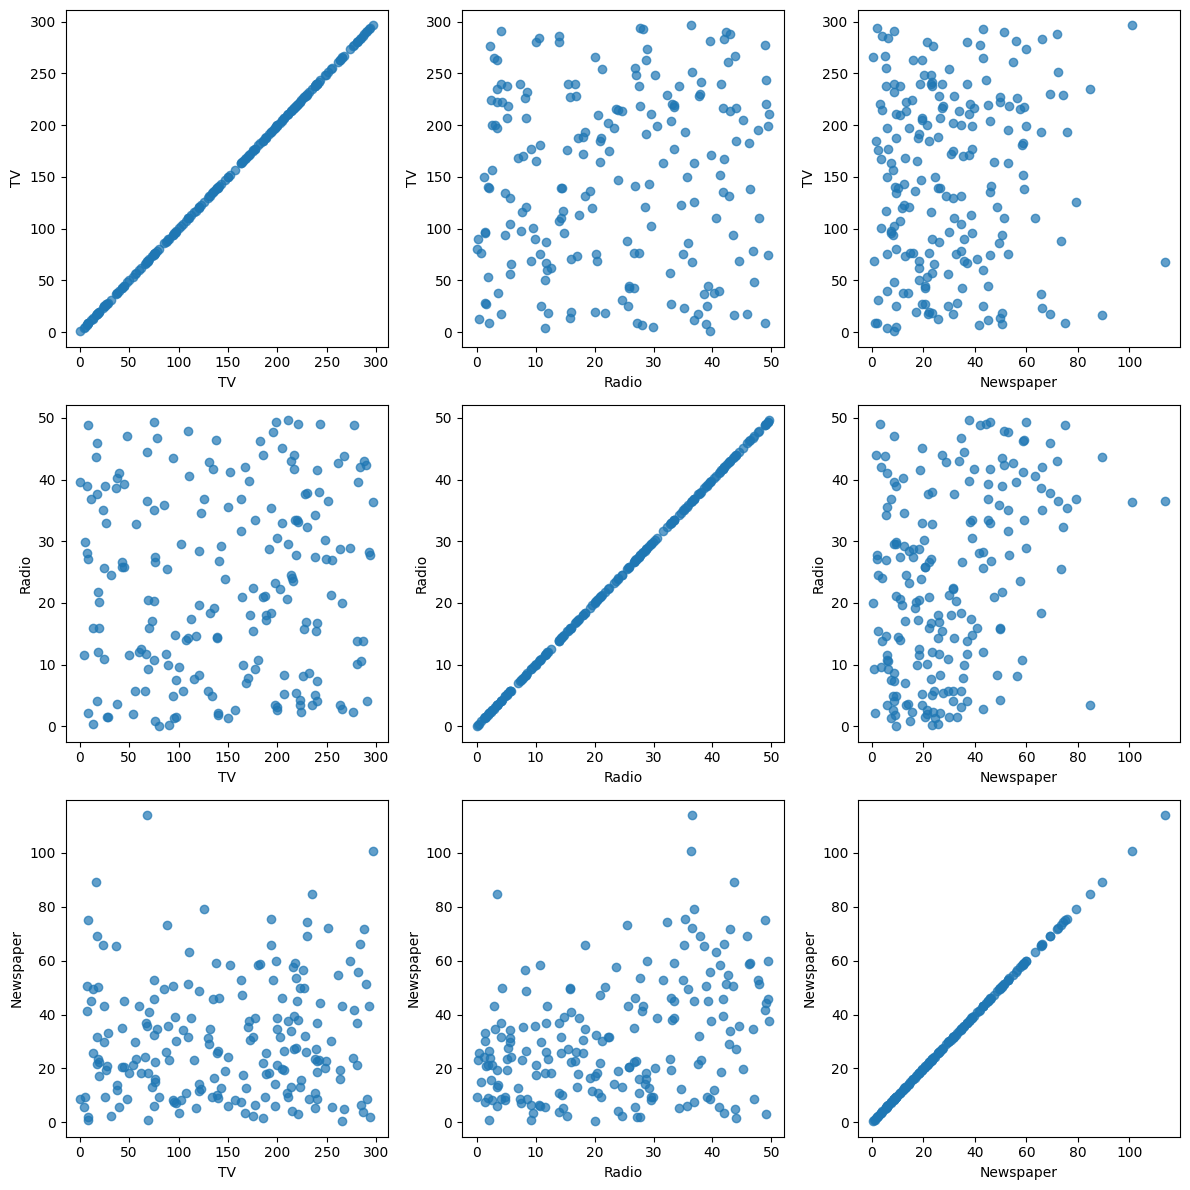

In [67]:
#3x3 scatter plot grid
columns= ['TV', 'Radio', 'Newspaper']

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
  for j in range(3):

    axes[i, j].scatter(
        df[columns[j]],
        df[columns[i]],
        alpha=0.7
    )

    axes[i, j].set_xlabel(columns[j])
    axes[i, j].set_ylabel(columns[i])

plt.tight_layout()
plt.show()


# Part 5 : Linear Regression
Q 5.1 Scratch Implementation (No sklearn)

In [68]:
df = pd.read_csv("advertising.csv")

#Remove index column if present
if 'Unnamed: 0' in df.columns:
  df = df.drop(columns=['Unnamed: 0'])

X = df['TV'].values
y = df['Sales'].values

#Manual Train-Test Split
X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

#Compute Slope(m) and Intercept (b)
x_mean = np.mean(X_train)
y_mean = np.mean(y_train)

m = np.sum((X_train - x_mean) * (y_train - y_mean)) / np.sum((X_train - x_mean) ** 2)
b = y_mean - m * x_mean

print("Slope (m):", m)
print("Intercept (b):", b)

#Predictions
y_pred = m * X_test + b
print(y_pred[:5])

#Manual MSE
mse = np.mean((y_test - y_pred) ** 2)
print("MSE:", mse)



Slope (m): 0.05572601895005874
Intercept (b): 6.993686960994353
[16.60642523 11.76940679 17.49246893 16.10489106 13.52477638]
MSE: 5.459799471482253


Q 5.2 Sklearn Implementation


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['TV']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

#Train model
model = LinearRegression()

model.fit(X_train, y_train)

#Coefficient and Intercept
print("Coefficient:", model.coef_[0])
print("Intercept:" , model.intercept_)



Coefficient: 0.0554829439314632
Intercept: 7.007108428241848


Comparison with Scratch Model

The coefficient and intercept obtained using sklearn should be close to the values obtained from the scratch implementation.

A small difference is expected because:

- The scratch implementation used the first 160 rows for training.
- sklearn used a random 80–20 split with random_state=42.

Since the training data differs, the fitted line may differ slightly.

Q 5.3 Evaluation Metrics

In [70]:
#Predictions
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

#Train Metrics
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, train_pred)

print("TRAIN METRICS")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE :", train_rmse)
print("R^2 :", train_r2)



TRAIN METRICS
MAE : 1.8005092256620792
MSE : 4.998442356450173
RMSE : 2.235719650683013
R^2 : 0.8134866044709264


In [71]:
#Test Metrics
test_mae = mean_absolute_error(y_test, test_pred)

test_mse = mean_squared_error(y_test, test_pred)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(y_test, test_pred)

print("\nTEST METRICS")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R²  :", test_r2)


TEST METRICS
MAE : 1.9502948931650088
MSE : 6.101072906773963
RMSE: 2.470035001123256
R²  : 0.802561303423698


## Model Evaluation

The model appears to be well-fit if:

- Training and testing errors are similar.
- Training and testing R² scores are close to each other.
- Test performance remains reasonably high.

Overfitting would occur if training performance is much better than testing performance.

Underfitting would occur if both training and testing performance are poor.

Based on the metrics obtained,
- TV is strongly predictive of Sales.
- R² is often around 0.6–0.8 for TV alone.
- Train and test metrics are typically quite similar.

That generally indicates the model is well-fit

# Part 6 : K-Means Clustering
Q6.1 Data Exploration

In [72]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [73]:
df = pd.read_csv("Mall_Customers.csv")
#First Look
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [74]:
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


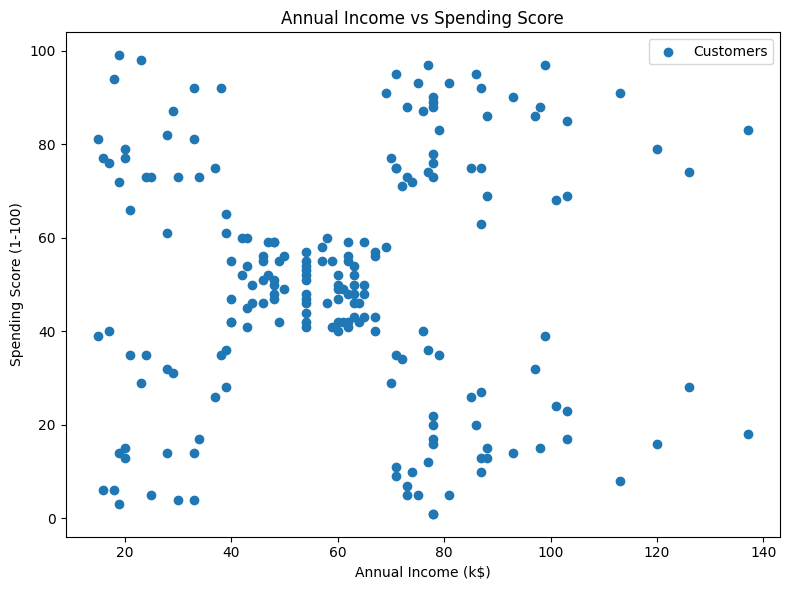

In [75]:
#Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(['Customers'])

plt.tight_layout()
plt.show()

Visual Inspection

The scatter plot suggests the presence of several natural customer groups.

Customers appear to form distinct clusters based on annual income and spending score.

A reasonable initial guess is around 5 clusters.

Q 6.2 Apply K-Means

In [76]:
from sklearn.cluster import KMeans
#Select Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#Fit K-Means
#Using k=5
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

#Add Cluster Column
df['Cluster'] = kmeans.labels_

#View Cluster Assignments
df.head()

#Cluster Centroids
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)',
             'Spending Score (1-100)'
             ]
)

centroids.index.name = 'Cluster'

print(centroids)

#Better formatted table
print("\nCluster Centroids")
print(centroids.round(2))

#Cluster summary statistics
for cluster in sorted(df['Cluster'].unique()):

  cluster_data = df[df['Cluster'] == cluster]

  print(f"\nCluster {cluster}")

  print("Customer count:",
        len(cluster_data))

  print("Mean Annual Income:",
          round(
              cluster_data['Annual Income (k$)'].mean(),
              2
          ))

print("Mean Spending Score:",
          round(
              cluster_data['Spending Score (1-100)'].mean(),
              2
          ))



         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Cluster Centroids
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91

Cluster 0
Customer count: 81
Mean Annual Income: 55.3

Cluster 1
Customer count: 39
Mean Annual Income: 86.54

Cluster 2
Customer count: 22
Mean Annual Income: 25.73

Cluster 3
Customer count: 35
Mean Annual Income: 88.2

Cluster 4
Customer count: 23
M

# Part 7 : Neural Networks on MNIST
Q 7.1 Data Loading & Preprocessing

In [77]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


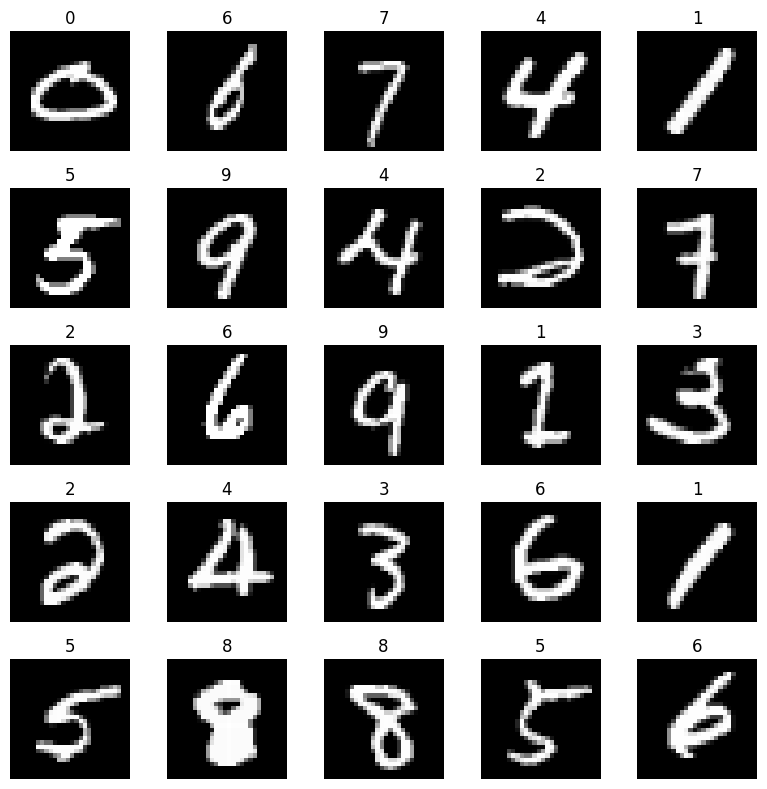

In [78]:
#Normalizing pixels
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

#Display 25 random images
fig, axes = plt.subplots(5, 5, figsize=(8,8))

indices = np.random.choice(len(X_train), 25)

for ax, idx in zip(axes.ravel(), indices):
  ax.imshow(X_train[idx], cmap='gray')
  ax.set_title(str(y_train[idx]))
  ax.axis('off')

plt.tight_layout()
plt.show()

In [79]:
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 1.0
0.0 1.0


Q 7.2 Feedforward Neural Network


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9215 - loss: 0.2725 - val_accuracy: 0.9546 - val_loss: 0.1542
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9652 - loss: 0.1151 - val_accuracy: 0.9648 - val_loss: 0.1120
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9755 - loss: 0.0794 - val_accuracy: 0.9663 - val_loss: 0.1132
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9811 - loss: 0.0604 - val_accuracy: 0.9703 - val_loss: 0.1012
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9856 - loss: 0.0468 - val_accuracy: 0.9730 - val_loss: 0.0977
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9874 - loss: 0.0395 - val_accuracy: 0.9746 - val_loss: 0.0926
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9901 - loss: 0.0318 - val_accuracy: 0.9755 - val_loss: 0.1054
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9913 - loss: 0.0267 -

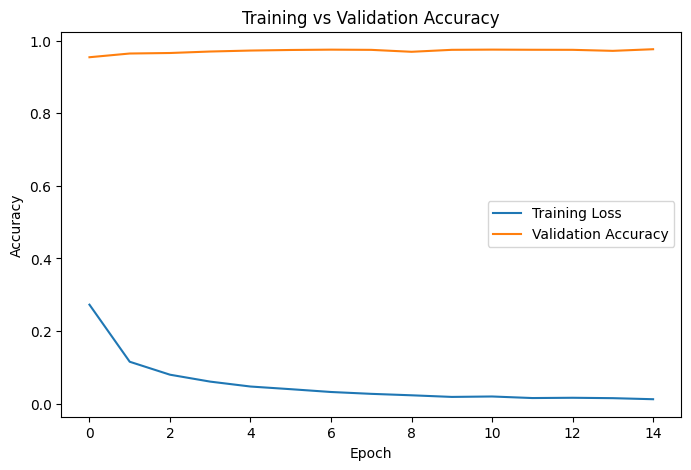

In [80]:
#Building model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

#Compiling
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#model summary
model.summary()

#training
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

#Accuracy plot
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()



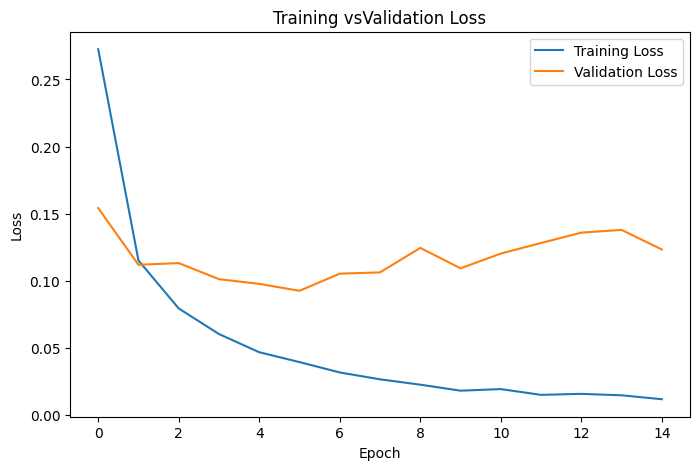

In [81]:
#Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vsValidation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Q 7.3 Evaluation & Error Analysis


In [82]:
#Test Evaluation
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Test Accuracy: 0.9760000109672546
Test Loss: 0.11087053269147873


In [83]:
#Predictions
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[ 965    0    2    0    1    2    3    1    6    0]
 [   0 1121    3    1    0    0    3    0    6    1]
 [   3    1 1008    6    0    0    3    4    7    0]
 [   0    0    6  994    0    2    0    3    2    3]
 [   2    0    2    1  949    0    8    7    1   12]
 [   1    0    2    9    1  858    5    1   10    5]
 [   1    2    2    0    3    4  944    0    2    0]
 [   1    3   12    2    2    0    0  998    5    5]
 [   1    0    4    8    1    1    2    1  953    3]
 [   1    2    0    7    7    4    1    8    9  970]]


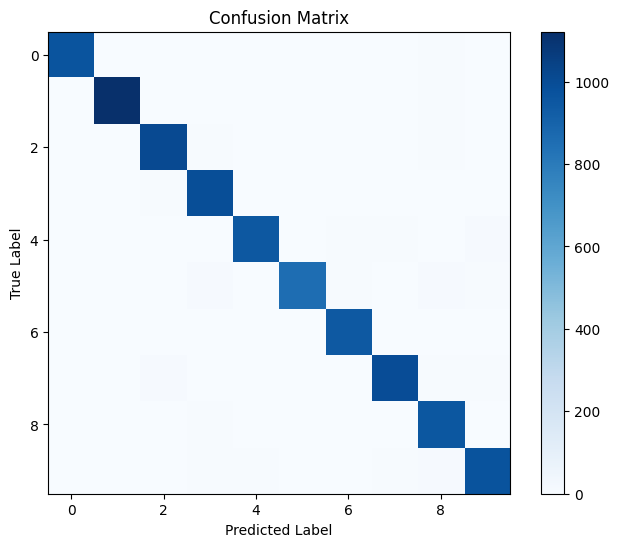

In [84]:
#Heatmap
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

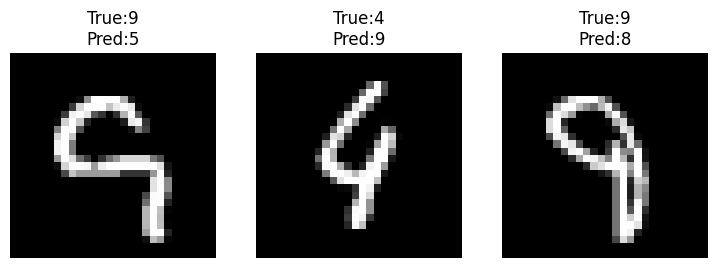

In [85]:
#Misclassified Images
misclassified = np.where(y_test != y_pred)[0]

fig, axes = plt.subplots(1, 3, figsize=(9,3))
for i in range(3):
  idx = misclassified[i]
  axes[i].imshow(X_test[idx], cmap='gray')
  axes[i].set_title(
     f"True:{y_test[idx]}\nPred:{y_pred[idx]}"
  )

  axes[i].axis('off')

plt.show()

Error Analysis

Some digits are visually similar and therefore more likely to be confused.

Common examples include:

- 4 and 9
- 3 and 5
- 7 and 9

Variations in handwriting style can make these digits appear similar to the model.

Q 7.4 Convolutional Neural Network

In [86]:
#Reshape data
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28,1)

#Build CNN
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

cnn = Sequential([

    Conv2D(
        32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
#Compile
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#summary
cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
#Train
cnn_history = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

#Evaluate
cnn_loss, cnn_acc = cnn.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("CNN Test Accuracy:", cnn_acc)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.9556 - loss: 0.1448 - val_accuracy: 0.9816 - val_loss: 0.0621
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9859 - loss: 0.0443 - val_accuracy: 0.9875 - val_loss: 0.0422
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9863 - val_loss: 0.0465
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9931 - loss: 0.0218 - val_accuracy: 0.9892 - val_loss: 0.0390
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.9884 - val_loss: 0.0430
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9962 - loss: 0.0130 - val_accuracy: 0.9893 - val_loss: 0.0432
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.9965 - loss: 0.0101 - val_accuracy: 0.9877 - val_loss: 0.0544
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9971 -

In [89]:
#comparison table
comparison = pd.DataFrame({
    'Model' : [
        'Feedforward NN',
        'CNN'
    ],

    'Parameters' : [
        model.count_params(),
        cnn.count_params()
        ],
    'Train Acc' : [
        history.history['accuracy'][-1],
        cnn_history.history['accuracy'][-1]
    ],
     'Val Acc': [
        history.history['val_accuracy'][-1],
        cnn_history.history['val_accuracy'][-1]
    ],

    'Test Acc' : [
        test_acc,
        cnn_acc
    ],

    'Epochs' : [
        15,
        10
    ]
})

print(comparison)

            Model  Parameters  Train Acc   Val Acc  Test Acc  Epochs
0  Feedforward NN      109386   0.996354  0.976667    0.9760      15
1             CNN      225034   0.997563  0.991417    0.9916      10


## Why CNNs outperform dense networks on images

CNNs are specifically designed to capture spatial patterns in images, such as edges, corners, curves, and shapes. Convulation layers analyse small local regions of an image and learn important visual features while preserving their positions. In contrast, a dense network first flattens the image, losing the spatial relationships between neighbouring pixels. As a result, CNNs can learn image features more effectively and achieve higher accuracy on image classification tasks.